In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from IPython.display import display

In [39]:
# Load data from JSON file (array of objects)
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# If your JSON is an array, not an object with "data" key:
df = pd.DataFrame(data)
# If label is boolean, you may want to convert it to int or str
df['label'] = df['label'].astype(int)  # Uncomment if needed

X = df['text']
y = df['label']

# show head
print(df.head())

                                                text  label
0                         mari riah ernia widyatmoko      0
1              taut hebat bonbon berani menang orang      1
2  wd keren mahaslot royal gan kasih juta hahaha ...      1
3                       jelek banget mantap mahaslot      1
4  wajah materialistis laku klaim freebet pepe kl...      1


c:\Users\Marvel Wilbert O\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=20. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 3 candidates, totalling 30 fits
Best parameters: {'rf__n_estimators': 400, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_depth': None, 'rf__class_weight': 'balanced'}
Best cross-validated score: 0.9099266086010959
   param_rf__n_estimators  mean_test_accuracy  mean_test_f1  \
0                     200            0.909034      0.909006   
1                     300            0.908853      0.908834   
2                     400            0.909944      0.909927   

   mean_test_precision  mean_test_recall  
0             0.909180          0.909034  
1             0.909014          0.908853  
2             0.910086          0.909944  


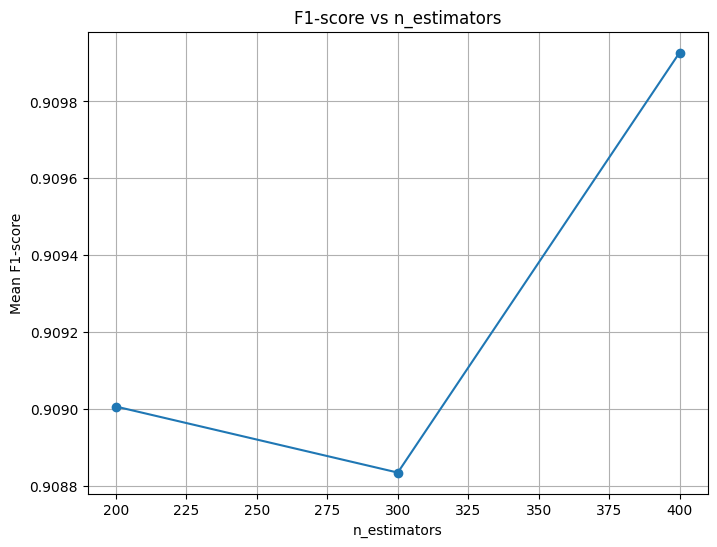

In [42]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline

# Load data from JSON file (array of objects)
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# TF-IDF vectorization (fit on all data for search)
# vectorizer = TfidfVectorizer(max_features=5000)
# X_tfidf = vectorizer.fit_transform(X)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Choose number of splits (5 or 10)
n_splits = 10  # Change to 5 or 10 as needed
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'rf__n_estimators': [200, 300, 400],
    'rf__max_depth': [None],
    'rf__min_samples_split': [2],
    'rf__min_samples_leaf': [1],
    'rf__class_weight': ['balanced']
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted')
}

# Grid Search with StratifiedKFold
search = RandomizedSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring=scoring,
    refit='f1',  # Optimize for weighted F1-score
    n_jobs=4,
    verbose=2,
    n_iter=20
)

search.fit(X, y)

print("Best parameters:", search.best_params_)
print("Best cross-validated score:", search.best_score_)

import pandas as pd

results = pd.DataFrame(search.cv_results_)
print(results[['param_rf__n_estimators', 'mean_test_accuracy', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall']])



import matplotlib.pyplot as plt

results = pd.DataFrame(search.cv_results_)
plt.figure(figsize=(8,6))
plt.plot(results['param_rf__n_estimators'], results['mean_test_f1'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Mean F1-score')
plt.title('F1-score vs n_estimators')
plt.grid(True)
plt.show()

results.to_csv("result/gridsearch_results.csv", index=False)



# Save model and vectorizer for future use
# joblib.dump(search.best_estimator_, 'result/rf_model_best.pkl')
# joblib.dump(vectorizer, 'result/tfidf_vectorizer.pkl')

In [ ]:

# Optionally, train on all data for deployment
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_tfidf, y)

# Save the model and vectorizer for future use
joblib.dump(model, 'rf_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

In [41]:
# Stratified K-Fold Cross Validation
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []
cv_scores = []
fold_reports = []
fold = 0
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = RandomForestClassifier(n_estimators=400, max_depth=None, n_jobs=4, min_samples_split=2, 
                                min_samples_leaf=1,  random_state=42, class_weight='balanced')
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    accu = accuracy_score(y_test, y_pred)
    cv_scores.append(accu)
    print("Fold {}: {}".format(fold + 1, accu))
    # Collect metrics for this fold
    report = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    fold_reports.append(report)
    display(pd.DataFrame(report).transpose())
    # fold += 1


# Calculate mean metrics
def mean_metric(metric):
    return np.mean([fold[metric]['f1-score'] for fold in fold_reports])

labels = sorted(list(set(y)))
metrics = ['precision', 'recall', 'f1-score']
mean_results = {}

# Per-class averages
for label in labels:
    mean_results[f"class {label}"] = {
        m: np.mean([fold[str(label)][m] for fold in fold_reports]) for m in metrics
    }

# Global averages
mean_results['accuracy'] = {"score": np.mean([fold['accuracy'] for fold in fold_reports])}
mean_results['macro avg'] = {
    m: np.mean([fold['macro avg'][m] for fold in fold_reports]) for m in metrics
}
mean_results['weighted avg'] = {
    m: np.mean([fold['weighted avg'][m] for fold in fold_reports]) for m in metrics
}

# Convert to DataFrame
results_df = pd.DataFrame(mean_results).T

print("Final averaged metrics across folds:")
display(results_df)

# Show per-fold accuracies as well
fold_acc_df = pd.DataFrame({
    "Fold": range(1, n_splits + 1),
    "Accuracy": cv_scores
})
print("Per-fold accuracy:")
display(fold_acc_df)

# Show overall confusion matrix
print("Confusion Matrix across all folds:")
display(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred)))



Fold 1: 0.9009090909090909


,precision,recall,f1-score,support
0,0.903292,0.876248,0.889564,501.000000
1,0.899023,0.921536,0.910140,599.000000
accuracy,0.900909,0.900909,0.900909,0.900909
macro avg,0.901157,0.898892,0.899852,1100.000000
weighted avg,0.900967,0.900909,0.900769,1100.000000


Fold 2: 0.9009090909090909


,precision,recall,f1-score,support
0,0.884314,0.900200,0.892186,501.000000
1,0.915254,0.901503,0.908326,599.000000
accuracy,0.900909,0.900909,0.900909,0.900909
macro avg,0.899784,0.900851,0.900256,1100.000000
weighted avg,0.901162,0.900909,0.900975,1100.000000


Fold 3: 0.9118181818181819


...

,precision,recall,f1-score,score
class 0,0.902479,0.899716,0.900990,NaN
class 1,0.916451,0.918491,0.917398,NaN
accuracy,NaN,NaN,NaN,0.909944
macro avg,0.909465,0.909104,0.909194,NaN
weighted avg,0.910086,0.909944,0.909927,NaN


Per-fold accuracy:


,Fold,Accuracy
0,1,0.900909
1,2,0.900909
2,3,0.911818
3,4,0.918107
4,5,0.918107
5,6,0.911738
6,7,0.923567
7,8,0.887170
8,9,0.904459
9,10,0.922657


Confusion Matrix across all folds:


,0,1
0,4504,502
1,488,5499


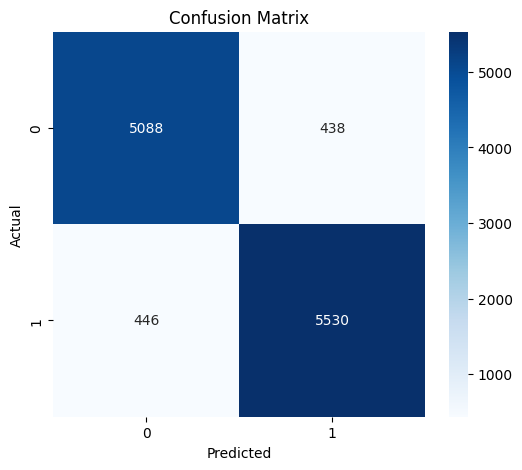

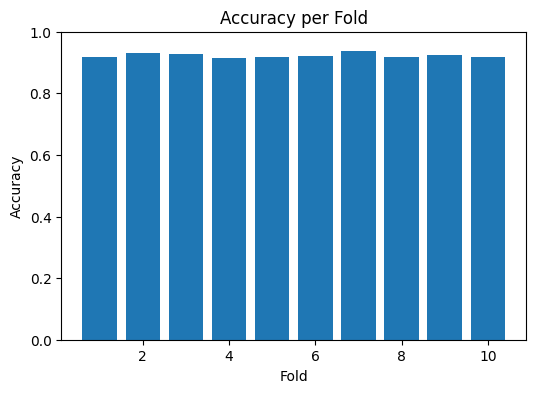

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ...existing code...

# After printing the confusion matrix and classification report:
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Accuracy scores bar plot
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(cv_scores) + 1), cv_scores)
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy per Fold')
plt.show()

In [11]:
from sklearn.svm import SVC

# Stratified K-Fold Cross Validation
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []
cv_scores = []
fold_reports = []
fold = 0
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42, gamma='scale')
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    accu = accuracy_score(y_test, y_pred)
    cv_scores.append(accu)
    print("Fold {}: {}".format(fold + 1, accu))
    # Collect metrics for this fold
    report = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    fold_reports.append(report)
    display(pd.DataFrame(report).transpose())
    # fold += 1


# Calculate mean metrics
def mean_metric(metric):
    return np.mean([fold[metric]['f1-score'] for fold in fold_reports])

labels = sorted(list(set(y)))
metrics = ['precision', 'recall', 'f1-score']
mean_results = {}

# Per-class averages
for label in labels:
    mean_results[f"class {label}"] = {
        m: np.mean([fold[str(label)][m] for fold in fold_reports]) for m in metrics
    }

# Global averages
mean_results['accuracy'] = {"score": np.mean([fold['accuracy'] for fold in fold_reports])}
mean_results['macro avg'] = {
    m: np.mean([fold['macro avg'][m] for fold in fold_reports]) for m in metrics
}
mean_results['weighted avg'] = {
    m: np.mean([fold['weighted avg'][m] for fold in fold_reports]) for m in metrics
}

# Convert to DataFrame
results_df = pd.DataFrame(mean_results).T

print("Final averaged metrics across folds:")
display(results_df)

# Show per-fold accuracies as well
fold_acc_df = pd.DataFrame({
    "Fold": range(1, n_splits + 1),
    "Accuracy": cv_scores
})
print("Per-fold accuracy:")
display(fold_acc_df)

# Show overall confusion matrix
print("Confusion Matrix across all folds:")
display(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred)))


Fold 1: 0.9417897480451781


,precision,recall,f1-score,support
0,0.921875,0.960217,0.940655,553.00000
1,0.961739,0.924749,0.942882,598.00000
accuracy,0.941790,0.941790,0.941790,0.94179
macro avg,0.941807,0.942483,0.941768,1151.00000
weighted avg,0.942586,0.941790,0.941812,1151.00000


Fold 2: 0.9417897480451781


,precision,recall,f1-score,support
0,0.917526,0.965642,0.940969,553.00000
1,0.966608,0.919732,0.942588,598.00000
accuracy,0.941790,0.941790,0.941790,0.94179
macro avg,0.942067,0.942687,0.941778,1151.00000
weighted avg,0.943026,0.941790,0.941810,1151.00000


Fold 3: 0.9391304347826087


...

,precision,recall,f1-score,score
class 0,0.915667,0.960369,0.937475,NaN
class 1,0.961619,0.918174,0.939384,NaN
accuracy,NaN,NaN,NaN,0.938445
macro avg,0.938643,0.939272,0.938430,NaN
weighted avg,0.939543,0.938445,0.938467,NaN


Per-fold accuracy:


,Fold,Accuracy
0,1,0.941790
1,2,0.941790
2,3,0.939130
3,4,0.933913
4,5,0.940870
5,6,0.941739
6,7,0.945217
7,8,0.930435
8,9,0.940870
9,10,0.928696


Confusion Matrix across all folds:


,0,1
0,5307,219
1,489,5487


In [10]:
from sklearn.model_selection import GridSearchCV
with open('fetched_data_final_dedup_3.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# TF-IDF vectorization (fit on all data for search)
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Choose number of splits (5 or 10)
n_splits = 10  # Change to 5 or 10 as needed
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 5, 10],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

svm = SVC(class_weight='balanced', random_state=42)
grid = GridSearchCV(svm, param_grid, cv=5, scoring='f1_macro', verbose=2, n_jobs=4)
grid.fit(X_tfidf, y)

print("Best Params:", grid.best_params_)
print("Best cross-validated score:", grid.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validated score: 0.8924700075144532
